Meta öğrenme, "öğrenmeyi öğrenme" olarak tanımlanabilir ve genellikle bir modelin yeni görevleri hızlı bir şekilde öğrenebilmesi için geliştirilmiş bir algoritma tasarımı sürecini ifade eder. Meta öğrenme algoritmaları, bir modelin farklı görevleri öğrenmesi ve sonra bu öğrenmeyi başka görevlere genellemesi için optimize edilir. İşte meta öğrenme için popüler bir öğrenme algoritması:

Model-Agnostik Meta Öğrenme (MAML)
Model-Agnostik Meta Öğrenme (MAML), meta öğrenmenin en yaygın kullanılan algoritmalarından biridir. MAML, modelin birkaç örnekte hızlı bir şekilde yeni görevler öğrenmesini sağlar.

MAML'nin Temel Prensibi:
MAML, bir modelin başlangıç parametrelerini (başlangıç ağırlıkları) böyle bir şekilde optimize eder ki, model, yalnızca birkaç iterasyonla yeni bir görev üzerinde iyi performans gösterebilsin. Bu süreç, modelin genelleme yeteneğini artırır.

Adımlar:
Meta-Öğrenme: Bir meta-öğrenici, modelin farklı görevlerde öğrenme yeteneğini optimize eder. Bu adım, modelin öğrenmesini hızlandıracak başlangıç parametrelerini bulmayı hedefler.
Task-Specific Learning: Yeni bir görevle karşılaşıldığında, model sadece birkaç iterasyonla bu yeni görevi öğrenebilir. Bu, modelin meta öğrenme sürecinde optimize edilen parametrelerle yapılır.
Meta-Update: Her görevde modelin parametrelerini güncelleriz. Bu, genellikle bir tür gradient descent kullanılarak yapılır.

In [1]:
import torch
from torch import nn
import torch.optim as optim
from torch.autograd import Variable

class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)

def train_meta_model(model, tasks, num_epochs=10):
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        total_loss = 0
        for task in tasks:
            # Her görev için modelin parametrelerini sıfırlıyoruz
            task_model = MLP(input_size=task.input_size, hidden_size=task.hidden_size, output_size=task.output_size)

            # Hedef görevde birkaç adımda öğrenme
            task_optimizer = optim.Adam(task_model.parameters(), lr=0.01)

            for step in range(5):  # 5 iterasyon
                data, target = task.get_data()
                data, target = Variable(data), Variable(target)

                task_optimizer.zero_grad()
                output = task_model(data)
                loss = nn.MSELoss()(output, target)
                loss.backward()
                task_optimizer.step()

            # Meta-güncelleme işlemi (genel öğrenme)
            total_loss += loss.item()

        print(f'Epoch {epoch+1}, Loss: {total_loss / len(tasks)}')

# Bu şekilde bir görev kümesi tanımlayarak MAML'yi uygulayabilirsiniz


In [26]:
import numpy as np  # Veri işlemleri için gerekli kütüphane
import pandas as pd  # Veri işlemleri ve CSV dosya girişi/çıkışı için gerekli kütüphane

from google.colab import drive
drive.mount('/content/drive')

# Dosyayı oku
tsunami_verisi = pd.read_csv('/content/drive/MyDrive/melike Yalçın Kaplan/sources.csv', sep=",", header=0, index_col=0)
tsunami_verisi.head()  # Verinin ilk 5 satırını göster


,YEAR,MONTH,DAY,HOUR,MINUTE,CAUSE,VALIDITY,FOCAL_DEPTH,PRIMARY_MAGNITUDE,REGION_CODE,...,ALL_INJURIES,INJURY_TOTAL,ALL_FATALITIES,FATALITY_TOTAL,ALL_DAMAGE_MILLIONS,DAMAGE_TOTAL,ALL_HOUSES_DAMAGED,HOUSE_DAMAGE_TOTAL,ALL_HOUSES_DESTROYED,HOUSE_DESTRUCTION_TOTAL
SOURCE_ID,,,,,,,,,,,,,,,,,,,,,
1,-2000,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,50.0,...,NaN,NaN,NaN,3.0,NaN,4.0,NaN,NaN,NaN,NaN
3,-1610,NaN,NaN,NaN,NaN,6.0,4.0,NaN,NaN,50.0,...,NaN,NaN,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN
4,-1365,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,50.0,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
5,-1300,NaN,NaN,NaN,NaN,0.0,2.0,NaN,6.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,-760,NaN,NaN,NaN,NaN,0.0,2.0,NaN,NaN,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# ID verilerini kontrol et, correlatives yok.
# Ardından doğru bir şekilde reset_index işlemi yap.

tsunami_verisi.reset_index(drop=True, inplace=True)
tsunami_verisi.head()  # Verinin ilk 5 satırını göster


,YEAR,MONTH,DAY,HOUR,MINUTE,CAUSE,VALIDITY,FOCAL_DEPTH,PRIMARY_MAGNITUDE,REGION_CODE,...,ALL_INJURIES,INJURY_TOTAL,ALL_FATALITIES,FATALITY_TOTAL,ALL_DAMAGE_MILLIONS,DAMAGE_TOTAL,ALL_HOUSES_DAMAGED,HOUSE_DAMAGE_TOTAL,ALL_HOUSES_DESTROYED,HOUSE_DESTRUCTION_TOTAL
0,-2000,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,50.0,...,NaN,NaN,NaN,3.0,NaN,4.0,NaN,NaN,NaN,NaN
1,-1610,NaN,NaN,NaN,NaN,6.0,4.0,NaN,NaN,50.0,...,NaN,NaN,NaN,3.0,NaN,3.0,NaN,NaN,NaN,NaN
2,-1365,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,50.0,...,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
3,-1300,NaN,NaN,NaN,NaN,0.0,2.0,NaN,6.0,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-760,NaN,NaN,NaN,NaN,0.0,2.0,NaN,NaN,50.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
# Tekrar eden değerler ve NaN'ler
# Satır numaralarını kontrol et
print("Temizlemeden önce: ", tsunami_verisi.index)

# NaN değerlerini ve tekrar eden satırları temizle
tsunami_verisi.dropna()  # NaN değerlerini kaldır
tsunami_verisi.drop_duplicates()  # Tekrar eden satırları kaldır

print("Temizlemeden sonra: ", tsunami_verisi.index)


Temizlemeden önce:  RangeIndex(start=0, stop=2582, step=1)
Temizlemeden sonra:  RangeIndex(start=0, stop=2582, step=1)


In [29]:
tsunami_verisi['ULKE_SIKLIGI'] = tsunami_verisi.groupby(tsunami_verisi['COUNTRY'])['COUNTRY'].transform('count')


<Axes: title={'center': 'Ülkelere Göre Tsunami Sıklığı > 50'}, xlabel='COUNTRY'>

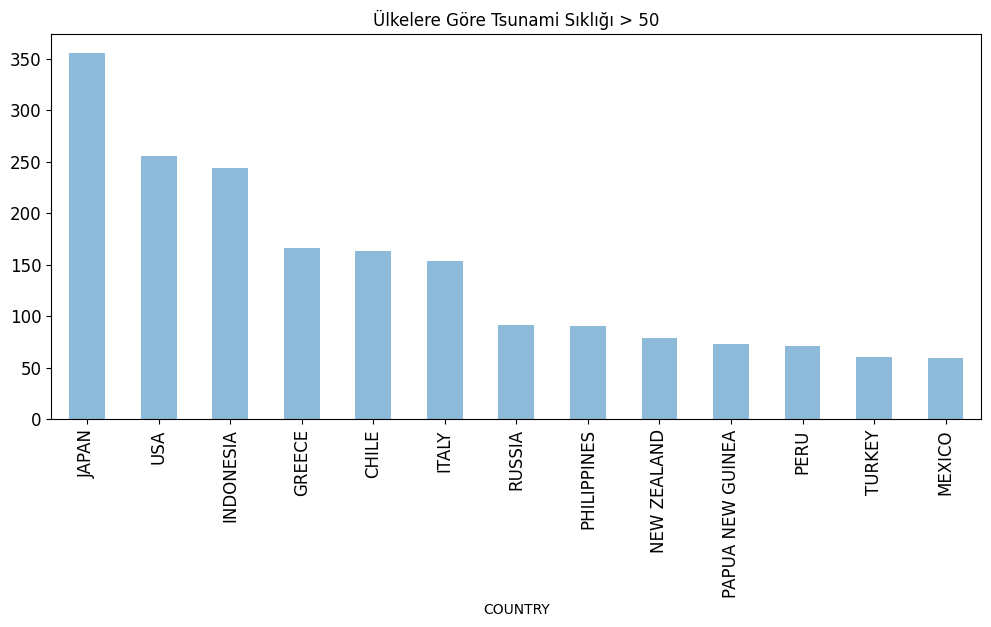

In [30]:
# Birçok ülkeden tsunami verisi
tsunami_verisi.COUNTRY[tsunami_verisi.ULKE_SIKLIGI > 50].value_counts().plot(kind='bar',
                                             legend=False,
                                             figsize=(12,5),
                                             title="Ülkelere Göre Tsunami Sıklığı > 50",
                                             fontsize=12,
                                             alpha=0.5
                                            )


<Axes: title={'center': 'Ülkelere Göre Tsunami Sıklığı (Yıl >= 1950)'}, xlabel='COUNTRY'>

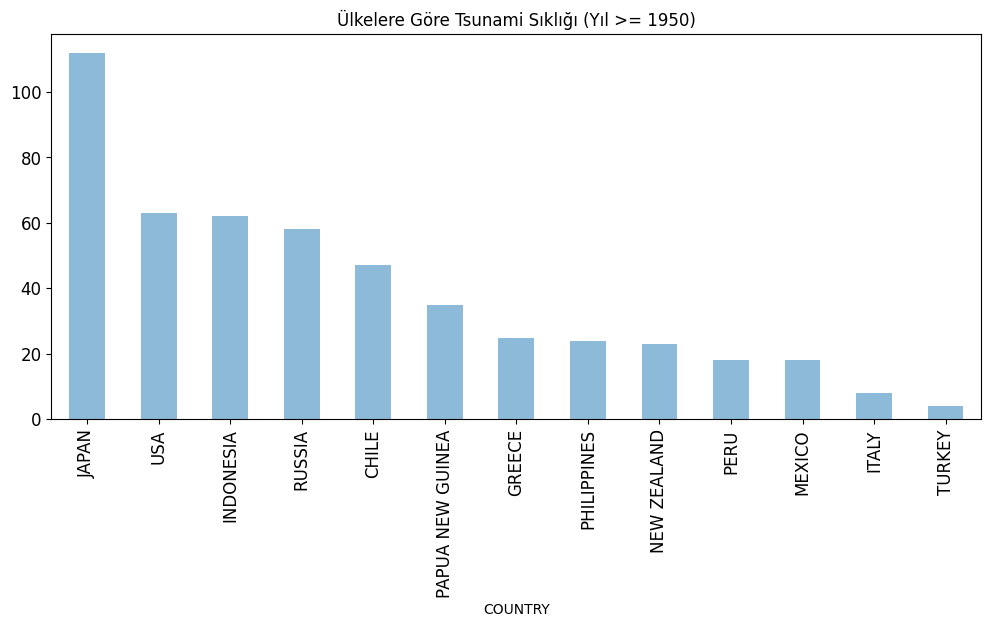

In [31]:
# Tsunamiler sıklığı (yıl > 1950)
tsunami_verisi.COUNTRY[(tsunami_verisi.YEAR >= 1950) & (tsunami_verisi.ULKE_SIKLIGI > 50)].value_counts().plot(kind='bar',
                                             legend=False,
                                             figsize=(12,5),
                                             title="Ülkelere Göre Tsunami Sıklığı (Yıl >= 1950)",
                                             fontsize=12,
                                             alpha=0.5
                                            )


In [39]:
# Bölgelerle eşleştirme ve sıklık hesaplama
bölgeler = {77:'Batı Afrika Kıyısı', 78:'Orta Afrika', 73:'Kuzeydoğu Atlantik Okyanusu', 72:'Kuzeybatı Atlantik Okyanusu',
            70:'Güneydoğu Atlantik Okyanusu', 71:'Güneybatı Atlantik Okyanusu', 75:'ABD ve Kanada Doğu Kıyısı, St Pierre ve Miquelon',
            76:'Meksika Körfezi', 74:'Karayip Denizi', 40:'Karadeniz ve Hazar Denizi', 50:'Akdeniz', 30:'Kızıldeniz ve Basra Körfezi',
            60:'Hindistan Okyanusu (Avustralya batı kıyısı dahil)', 87:'Alaska (Aleut Adaları dahil)', 84:'Çin, Kuzey ve Güney Kore, Filipinler, Tayvan',
            81:'Avustralya Doğu Kıyısı, Yeni Zelanda, Güney Pasifik Adaları', 80:'Hawaii, Johnston Adası, Midway Adası',
            83:'Doğu Endonezya (Pasifik Okyanusu) ve Malezya', 82:'Yeni Kaledonya, Yeni Gine, Solomon Adaları, Vanuatu',
            86:'Kamçatka ve Kuril Adaları', 85:'Japonya', 88:'Kuzey ve Orta Amerika Batı Kıyısı', 89:'Güney Amerika Batı Kıyısı'}

tsunami_verisi['REGIONS'] = tsunami_verisi['REGION_CODE'].map(bölgeler)
tsunami_verisi['REGIONS_FRECUENCY'] = tsunami_verisi.groupby(tsunami_verisi.REGIONS)['REGIONS'].transform('count')

<Axes: title={'center': 'Bölgelere Göre Tsunamiler'}, ylabel='REGIONS'>

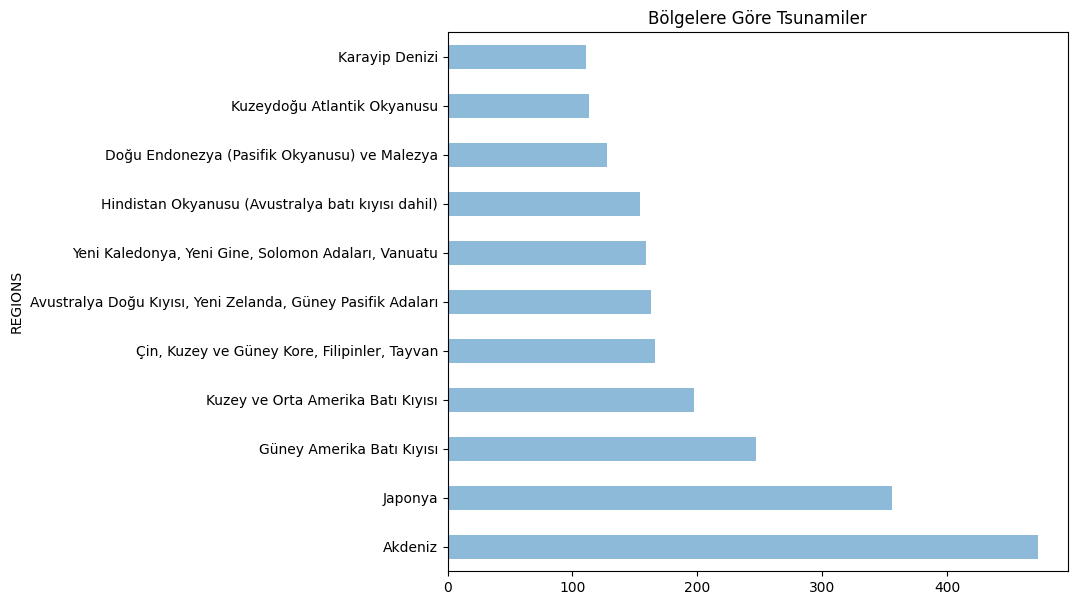

In [43]:
# Bölgeler sütununda sıklığı 100'den fazla olanları seçip grafiğini çizme
tsunami_verisi.REGIONS[tsunami_verisi.REGIONS_FRECUENCY > 100].value_counts().plot(
    kind='barh',
    legend=False,
    figsize=(8, 7),
    title="Bölgelere Göre Tsunamiler",
    alpha=0.5
)


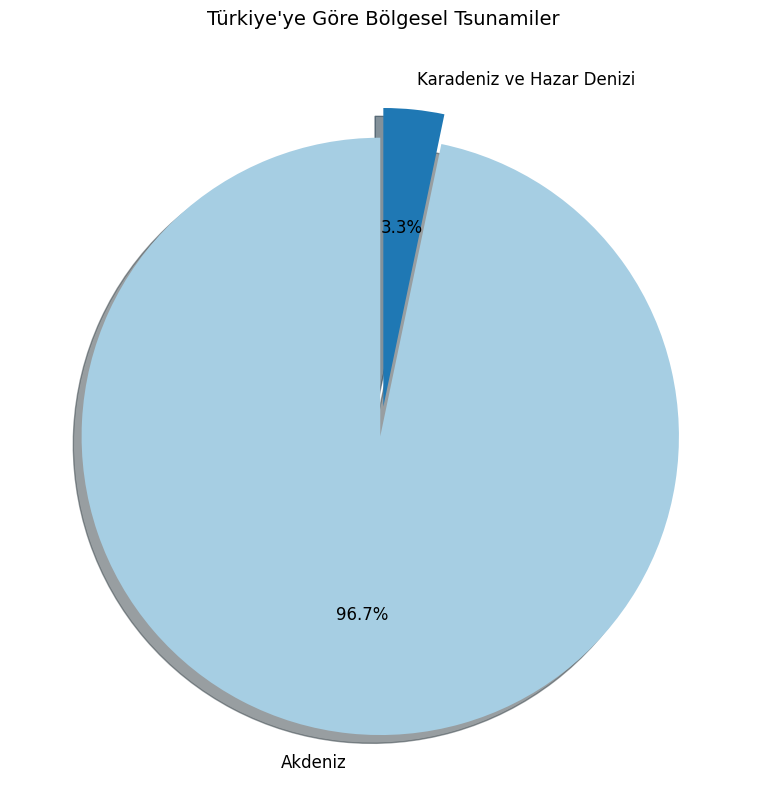

In [46]:
import matplotlib.pyplot as plt

# Türkiye verilerini filtreleme ve frekans hesaplama
turkiye_regions = tsunami_verisi.REGIONS[tsunami_verisi.COUNTRY == 'TURKEY'].value_counts()

# Dilimleri patlatma (en büyük dilimi vurgulamak için)
explode = [0.1 if i == turkiye_regions.max() else 0 for i in turkiye_regions]

# Renk paleti seçimi
colors = plt.cm.Paired(range(len(turkiye_regions)))

# Pasta grafiği çizimi
plt.figure(figsize=(10, 8))
turkiye_regions.plot(
    kind='pie',
    explode=explode,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12},
    legend=False
)

# Başlık ekleme
plt.title("Türkiye'ye Göre Bölgesel Tsunamiler", fontsize=14)
plt.ylabel('')  # Y eksenini kaldır
plt.tight_layout()  # Yerleşimi optimize et
plt.show()


In [47]:
# Tsunami nedenlerini tanımlama (0-11)
nedenler = {
    0: 'Bilinmeyen',
    1: 'Deprem',
    2: 'Şüpheli Deprem',
    3: 'Deprem ve Toprak Kayması',
    4: 'Volkan ve Deprem',
    5: 'Volkan, Deprem ve Toprak Kayması',
    6: 'Volkan',
    7: 'Volkan ve Toprak Kayması',
    8: 'Toprak Kayması',
    9: 'Meteorolojik',
    10: 'Patlama',
    11: 'Astronomik Gelgit'
}

# Nedenleri 'CAUSES' sütununa eşleme
tsunami_verisi['NEDENLER'] = tsunami_verisi['CAUSE'].map(nedenler)

# Nedenlere göre sıklığı hesaplama
tsunami_verisi['NEDENLER_SIKLIGI'] = tsunami_verisi.groupby(tsunami_verisi.NEDENLER)['NEDENLER'].transform('count')


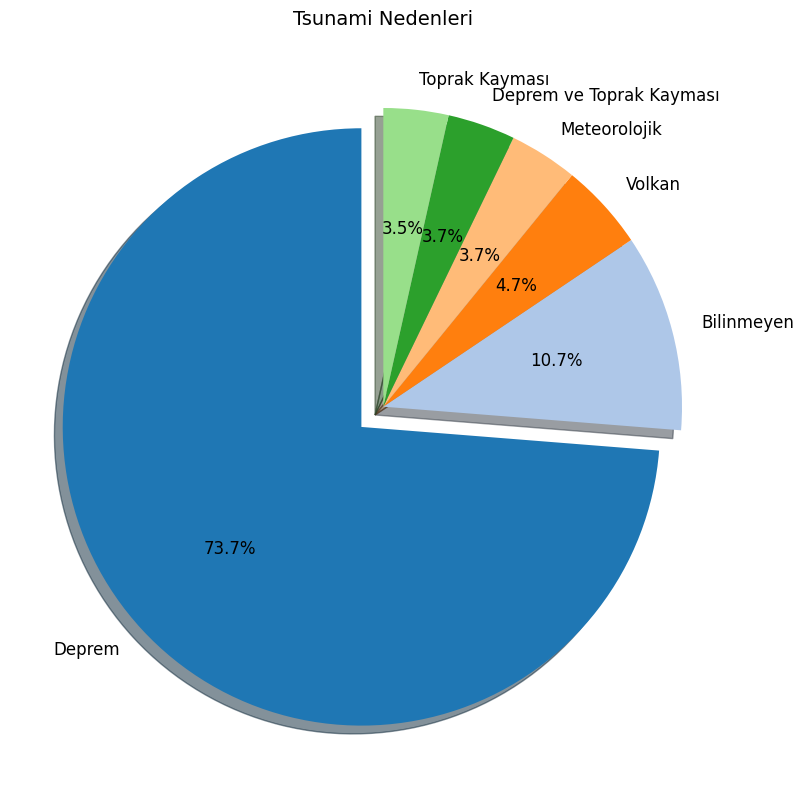

In [48]:
import matplotlib.pyplot as plt

# 50 veya daha fazla sıklığa sahip nedenleri filtreleme
nedenler_sıklık = tsunami_verisi.NEDENLER[tsunami_verisi.NEDENLER_SIKLIGI >= 50].value_counts()

# Dilimleri patlatma (en büyük dilimi vurgulamak için)
explode = [0.1 if i == nedenler_sıklık.max() else 0 for i in nedenler_sıklık]

# Renk paleti seçimi
colors = plt.cm.tab20(range(len(nedenler_sıklık)))

# Pasta grafiği çizimi
plt.figure(figsize=(10, 8))
nedenler_sıklık.plot(
    kind='pie',
    explode=explode,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    shadow=True,
    textprops={'fontsize': 12},
    legend=False
)

# Başlık ekleme
plt.title("Tsunami Nedenleri", fontsize=14)
plt.ylabel('')  # Y eksenini kaldır
plt.tight_layout()  # Yerleşimi optimize et
plt.show()


<Axes: ylabel='COUNTRY'>

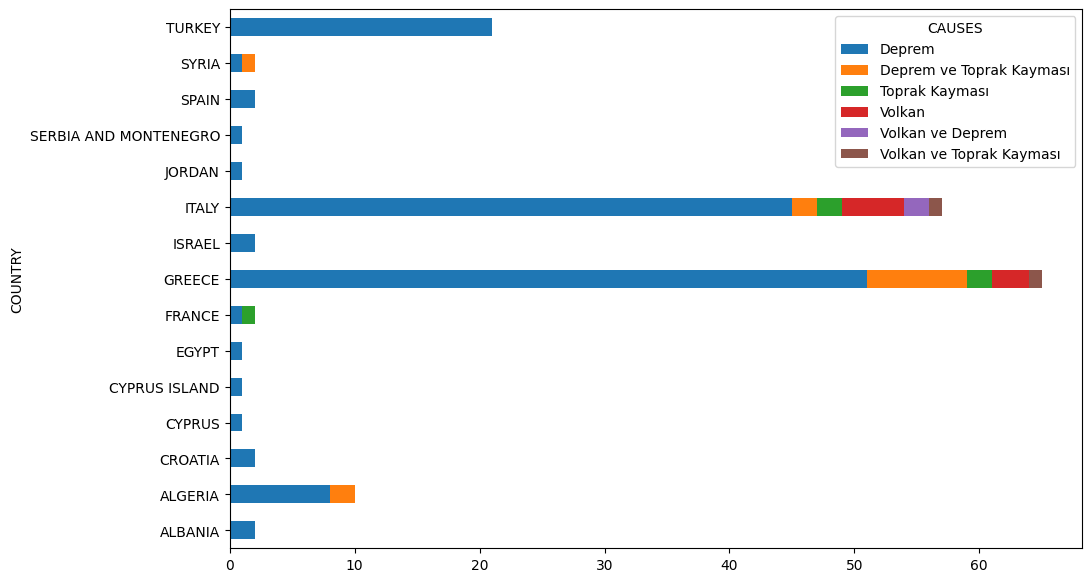

In [53]:
# Tsunami verisine 'CAUSES' sütunu ekleme (eğer henüz eklenmemişse)
nedenler = {
    0: 'Bilinmeyen',
    1: 'Deprem',
    2: 'Şüpheli Deprem',
    3: 'Deprem ve Toprak Kayması',
    4: 'Volkan ve Deprem',
    5: 'Volkan, Deprem ve Toprak Kayması',
    6: 'Volkan',
    7: 'Volkan ve Toprak Kayması',
    8: 'Toprak Kayması',
    9: 'Meteorolojik',
    10: 'Patlama',
    11: 'Astronomik Gelgit'
}

# 'CAUSES' sütununu 'CAUSE' sütunundaki sayısal verilere göre oluşturuyoruz
tsunami_verisi['CAUSES'] = tsunami_verisi['CAUSE'].map(nedenler)

# Akdeniz bölgesindeki tsunami verilerini filtreleme (REGION_CODE == 50)
tsunami_bolgeleri_akdeniz = tsunami_verisi[tsunami_verisi['REGION_CODE'] == 50]

# Bilinmeyen nedenleri ve geçerlilik skoru 3'ün altındaki verileri dışarıda bırakma
tsunami_bolgeleri_akdeniz_bilinmeyen_yok = tsunami_bolgeleri_akdeniz[
    (tsunami_bolgeleri_akdeniz['CAUSES'] != 'Bilinmeyen') &
    (tsunami_bolgeleri_akdeniz['VALIDITY'] >= 3.0)
]

# Ülke ve nedenlere göre gruplama
tsunami_akdeniz_neden_grup = tsunami_bolgeleri_akdeniz_bilinmeyen_yok.groupby(['COUNTRY', 'CAUSES'])

# Sayıları hesaplama ve her ülkenin nedenlerinin sıklığını normalleştirme
sayilar = tsunami_akdeniz_neden_grup.size().unstack().fillna(0)
normed_subnet = sayilar.div(sayilar.sum(1), axis=0)

# Yığılmış (stacked) çubuk grafik çizimi
sayilar.plot(kind='barh', legend=True, figsize=(11, 7), stacked=True)


<Axes: ylabel='COUNTRY'>

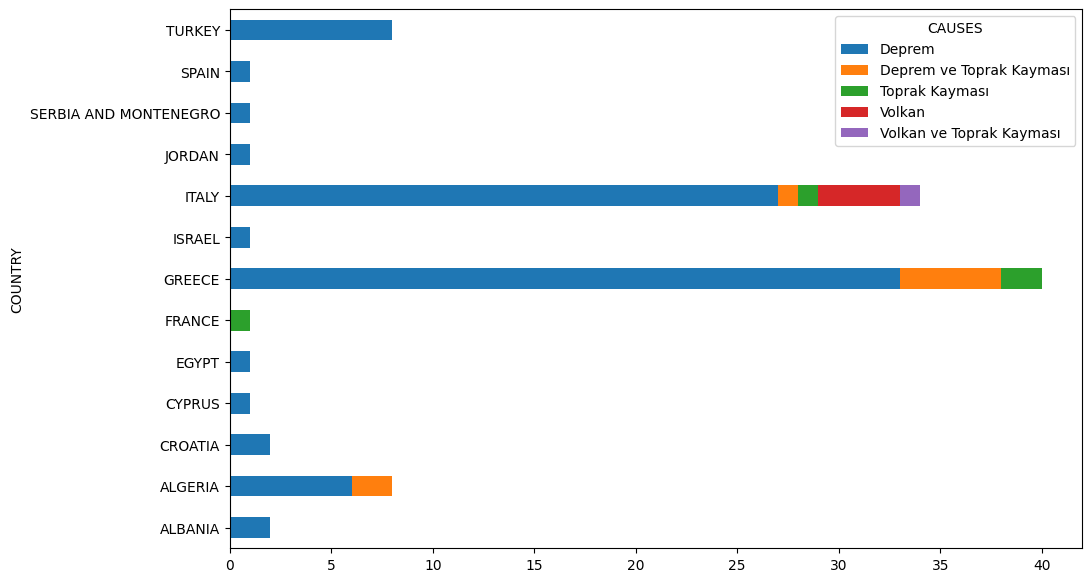

In [57]:
# 1800 yılı ve sonrasındaki, geçerliliği en az 3 olan tsunami verilerini filtreleme
tsunami_bolgeleri_akdeniz_bilinmeyen_yok_1800 = tsunami_bolgeleri_akdeniz_bilinmeyen_yok[
    (tsunami_bolgeleri_akdeniz_bilinmeyen_yok['YEAR'] >= 1800) &
    (tsunami_bolgeleri_akdeniz_bilinmeyen_yok['VALIDITY'] >= 3.0)
]

# Ülke ve nedenlere göre gruplama
tsunami_akdeniz_bilinmeyen_yok_1800_grup = tsunami_bolgeleri_akdeniz_bilinmeyen_yok_1800.groupby(['COUNTRY', 'CAUSES'])

# Sayıları hesaplama ve her ülkenin nedenlerinin sıklığını normalleştirme
sayilar = tsunami_akdeniz_bilinmeyen_yok_1800_grup.size().unstack().fillna(0)
normed_subnet = sayilar.div(sayilar.sum(1), axis=0)

# Yığılmış (stacked) çubuk grafik çizimi
sayilar.plot(kind='barh', legend=True, figsize=(11, 7), stacked=True)


<Axes: xlabel='DAMAGE_TOTAL'>

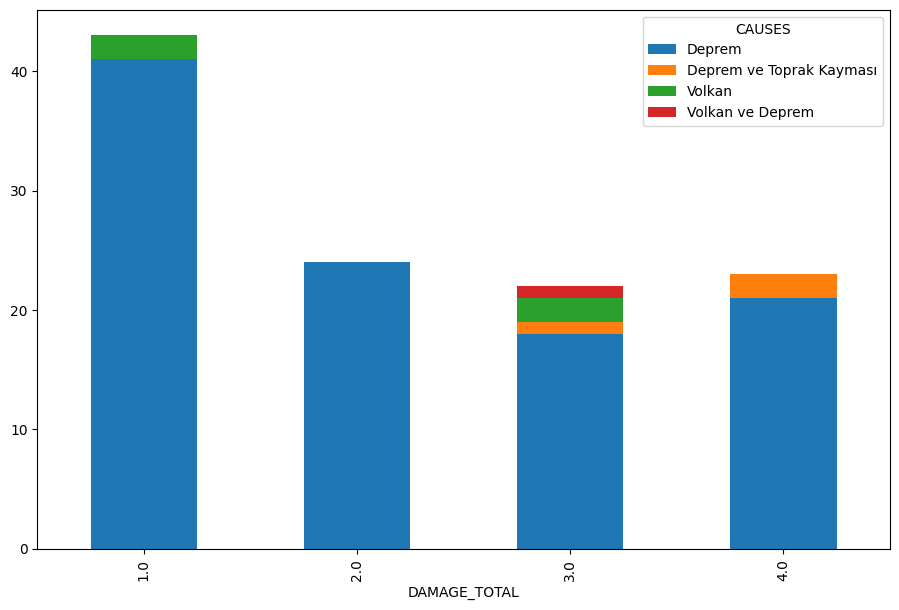

In [55]:
# Japonya bölgesindeki, 1700 ve sonrasındaki tsunami verilerini filtreleme
tsunami_bolgeleri_japonya_1700 = tsunami_verisi[
    (tsunami_verisi['YEAR'] >= 1700) &
    (tsunami_verisi['REGION_CODE'] == 85) &
    (tsunami_verisi['CAUSES'] != 'Bilinmeyen') &
    (tsunami_verisi['VALIDITY'] >= 3.0)
]

# Verilerin sayısını hesaplama
tsunami_bolgeleri_japonya_1700.count()

# 'DAMAGE_TOTAL' ve 'CAUSES' sütunlarına göre gruplama
tsunami_bolgeleri_japonya_1700_grup = tsunami_bolgeleri_japonya_1700.groupby(['DAMAGE_TOTAL', 'CAUSES'])

# Sayıları hesaplama ve her hasar türünün sıklığını normalleştirme
sayilar = tsunami_bolgeleri_japonya_1700_grup.size().unstack().fillna(0)
normed_subnet = sayilar.div(sayilar.sum(1), axis=0)

# Yığılmış (stacked) çubuk grafik çizimi
sayilar.plot(kind='bar', legend=True, figsize=(11, 7), stacked=True)


Yapay  Sinir ağları

In [68]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


# Veri setini yükle
from google.colab import drive
drive.mount('/content/drive')

# Dosyayı oku
tsunami_data = pd.read_csv('/content/drive/MyDrive/melike Yalçın Kaplan/sources.csv', sep=",", header=0, index_col=0)


# Eksik değerleri kaldırma ve X, y'yi oluşturma
data = tsunami_data[['YEAR', 'REGION_CODE', 'CAUSE', 'PRIMARY_MAGNITUDE', 'VALIDITY']].dropna()

X = data[['YEAR', 'REGION_CODE', 'CAUSE', 'PRIMARY_MAGNITUDE']]
y = data['VALIDITY']

# Kategorik verileri encode etme
label_encoder = LabelEncoder()
X['CAUSE'] = label_encoder.fit_transform(X['CAUSE'])

# Dizinleri sıfırlama
X.reset_index(drop=True, inplace=True)
y.reset_index(drop=True, inplace=True)

# Verileri ölçeklendirme
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Eğitim ve test verilerini ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Yapay sinir ağı modeli oluşturma
model = Sequential([
    Dense(16, input_dim=X_train.shape[1], activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Modeli derleme
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Modeli eğitme
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Model performansını değerlendirme
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Epoch 1/50


<ipython-input-68-836664766a4f>:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['CAUSE'] = label_encoder.fit_transform(X['CAUSE'])
/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0711 - loss: 1.0146 - val_accuracy: 0.0684 - val_loss: 0.4670
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0834 - loss: 0.1884 - val_accuracy: 0.0855 - val_loss: -0.4373
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0872 - loss: -0.7657 - val_accuracy: 0.1068 - val_loss: -1.5883
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1036 - loss: -1.9899 - val_accuracy: 0.1068 - val_loss: -3.0530
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1116 - loss: -3.5044 - val_accuracy: 0.1068 - val_loss: -4.8547
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1081 - loss: -5.4472 - val_accuracy: 0.1068 - val_loss: -7.1670
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0812 - loss: -8.1974 - val_accuracy: 0.1068 - val_loss: -10.1047
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.0869 - loss: -11.1217 - val_accuracy: 0.1068 - val_lo

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Veriyi temizleme ve encode etme
label_encoder = LabelEncoder()
tsunami_data['CAUSE'] = label_encoder.fit_transform(tsunami_data['CAUSE'])
data = tsunami_data[['YEAR', 'REGION_CODE', 'CAUSE', 'PRIMARY_MAGNITUDE', 'VALIDITY']].dropna()

X = data[['YEAR', 'REGION_CODE', 'CAUSE', 'PRIMARY_MAGNITUDE']]
y = data['VALIDITY']  # Sürekli bir değer varsayımı

# Veriyi ölçeklendirme
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Eğitim ve test setlerine ayırma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modeli oluşturma
model = Sequential([
    Dense(64, input_dim=X_train.shape[1], activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1)  # Çıkış katmanı (regresyon problemi için)
])

# Modeli derleme
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Modeli eğitme
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Modeli değerlendirme
loss, mae = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}, Test MAE: {mae:.4f}")

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.4856 - mae: 2.6541 - val_loss: 5.2937 - val_mae: 2.0390
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.3365 - mae: 1.8121 - val_loss: 3.0391 - val_mae: 1.4269
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.9866 - mae: 1.3666 - val_loss: 2.4843 - val_mae: 1.2349
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3073 - mae: 1.2636 - val_loss: 2.2008 - val_mae: 1.1768
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2844 - mae: 1.2144 - val_loss: 2.0499 - val_mae: 1.1194
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.1171 - mae: 1.1736 - val_loss: 2.0030 - val_mae: 1.1016
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1914 - mae: 1.1812 - val_loss: 1.9388 - val_mae: 1.0755
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2271 - mae: 1.1961 - val_loss: 1.8716 - val_mae: 1.0634
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.9637 - mae: 1.1341 - va